# Data Visualization in Python
**MTH1203 – Probability and Statistics | Group Research Assignment (Advent 2026)**
**Uganda Christian University – Faculty of Engineering, Design and Technology**

**Group members:
- 1 Wamala Stuart     M26B13/040
- 2 Ssettumba imran   M26B13/058
- 3 Ndahayo Dues est la  M26B13/071
- 4. Kaineyesu Mellissa   M26B13/021

This notebook demonstrates the main plot types discussed in our report using **Matplotlib**, **Seaborn**, **Pandas plotting** and **Plotly**.
The sample dataset is the **trainees.xlsx** file: exam results and training details for 12 IT trainees.



## 1. Setup

In [139]:
# Import the libraries used in this notebook
import numpy as np               
import pandas as pd                
import matplotlib.pyplot as plt    
import seaborn as sns              



In [140]:
# Plotly is used for interactive charts in Section 10
try:
    import plotly.express as px
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print("Plotly not installed - run: pip install plotly")



## 2. what is visualisation and its importance
Data visualization is the process of representing data using graphs, charts, diagrams, tables, and other visual forms so that information can be understood more easily.
Why is Visualization Important in Statistics and Data Analysis?
- Makes data easier to understand

Large amounts of numerical data can be difficult to read. Charts and graphs make the information simple and clear.

- Helps identify patterns and trends

Visualization can show whether something is increasing, decreasing, or staying constant.

For example, a line graph can show how sales change from January to December.

- Helps identify relationships

Graphs such as scatter plots can help us determine whether two variables are related.

Example:

Hours spent studying
Examination marks

We can visualize whether students who study more tend to get higher marks.





## 3. The sample dataset: trainees.xlsx
The file holds **12 trainees** (one per row). The variables are:

| Variable | Type | Meaning |
|---|---|---|
| Trainee | identifier | Name of the trainee |
| Track | categorical | Training track: Cybersecurity, Networking or Software |
| Sex | categorical | F or M |
| LabHours | numerical | Hours spent in the lab |
| Attendance | numerical | Attendance (%) |
| Score | numerical | Assessment score (%) |
| Result | categorical | Pass or Fail |
| Certified | categorical | Yes or No |



In [141]:
# Load the trainees dataset (the Excel file should be in the same folder as this notebook)
try:
    df = pd.read_excel("trainees.xlsx")
except (FileNotFoundError, ImportError):
    print("trainees.xlsx (or openpyxl) not available - using the same data typed in directly.")
    df = pd.DataFrame({
    "Trainee": ['Faith', 'Kevin', 'Miriam', 'Tonny', 'Sandra', 'Peter', 'Grace', 'Isaac', 'Diana', 'Martin', 'Ruth', 'Alex'],
    "Track": ['Networking', 'Software', 'Cybersecurity', 'Software', 'Networking', 'Cybersecurity', 'Software', 'Networking', 'Cybersecurity', 'Software', 'Networking', 'Cybersecurity'],
    "Sex": ['F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    "LabHours": [20, 9, 23, 7, 19, 13, 15, 11, 25, 8, 10, 17],
    "Attendance": [90, 62, 96, 57, 88, 72, 79, 66, 99, 59, 64, 84],
    "Score": [80, 47, 89, 41, 82, 63, 68, 54, 93, 46, 49, 74],
    "Result": ['Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass', 'Pass', 'Fail', 'Fail', 'Pass'],
    "Certified": ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes']
    })


df_sorted = df.sort_values("LabHours")
print("Rows and columns:", df.shape)
df

Rows and columns: (12, 8)


,Trainee,Track,Sex,LabHours,Attendance,Score,Result,Certified
0,Faith,Networking,F,20,90,80,Pass,Yes
1,Kevin,Software,M,9,62,47,Fail,No
2,Miriam,Cybersecurity,F,23,96,89,Pass,Yes
3,Tonny,Software,M,7,57,41,Fail,No
4,Sandra,Networking,F,19,88,82,Pass,Yes
5,Peter,Cybersecurity,M,13,72,63,Pass,No
6,Grace,Software,F,15,79,68,Pass,No
7,Isaac,Networking,M,11,66,54,Pass,No
8,Diana,Cybersecurity,F,25,99,93,Pass,Yes
9,Martin,Software,M,8,59,46,Fail,No


In [142]:
# Summary statistics for the numerical variables
df[["LabHours", "Attendance", "Score"]].describe().round(2)

,LabHours,Attendance,Score
count,12.00,12.00,12.0
mean,14.75,76.33,65.5
std,6.05,14.91,18.1
min,7.00,57.00,41.0
25%,9.75,63.50,48.5
50%,14.00,75.50,65.5
75%,19.25,88.50,80.5
max,25.00,99.00,93.0


## 4. Bar chart (comparing categories)
**Use when:** comparing a value (here the mean) across separate categories. Bars must start at zero.

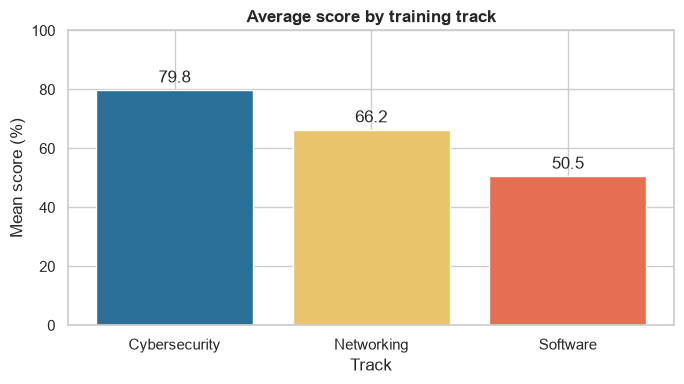

In [143]:
# Mean score per track, sorted from highest to lowest
avg = df.groupby("Track")["Score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg.index, avg.values, color=[TRACK_COLORS[t] for t in avg.index])
ax.bar_label(bars, fmt="%.1f", padding=3)           # print the value on each bar
ax.set_title("Average score by training track")
ax.set_xlabel("Track")
ax.set_ylabel("Mean score (%)")
ax.set_ylim(0, 100)                                
plt.tight_layout()
plt.show()

## 5. Line chart (change along an ordered scale)
**Use when:** showing a trend across an ordered variable, most often time. Our data has no date column, so we order the trainees by **lab hours** and see how score and attendance rise along that scale.

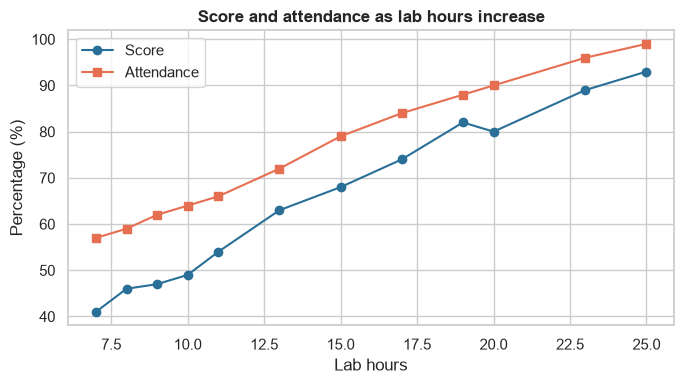

In [144]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_sorted["LabHours"], df_sorted["Score"], marker="o", label="Score", color="#2A6F97")
ax.plot(df_sorted["LabHours"], df_sorted["Attendance"], marker="s", label="Attendance", color="#E76F51")
ax.set_title("Score and attendance as lab hours increase")
ax.set_xlabel("Lab hours")
ax.set_ylabel("Percentage (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Histogram (distribution of one numerical variable)
**Use when:** you want the shape, centre and spread of a single numerical variable. With just 12 values we use a few wide bins.

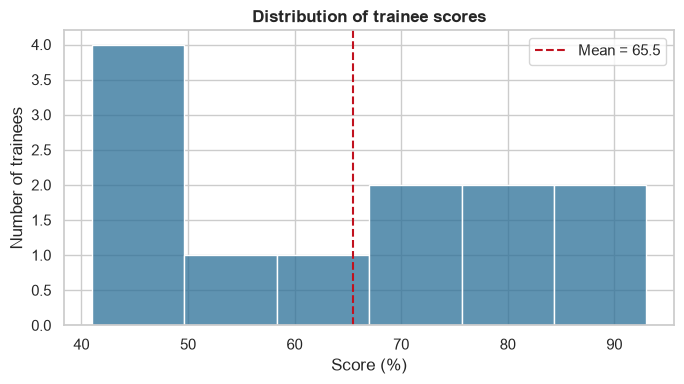

In [145]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["Score"], bins=6, color="#2A6F97",)
mean_score = df["Score"].mean()
ax.axvline(mean_score, color="#C1121F", linestyle="--", label=f"Mean = {mean_score:.1f}")
ax.set_title("Distribution of trainee scores")
ax.set_xlabel("Score (%)")
ax.set_ylabel("Number of trainees")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Scatter plot (relationship between two numerical variables)
**Use when:** checking whether two variables are related (correlation, trend, outliers).

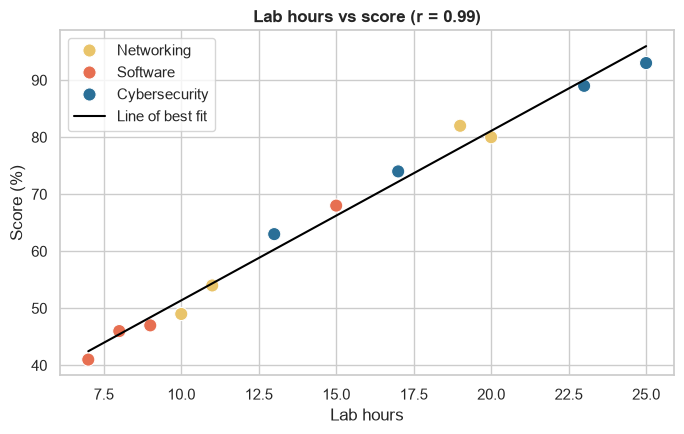

In [146]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=df, x="LabHours", y="Score", hue="Track", palette=TRACK_COLORS,
                s=90, ax=ax)

# Add a straight line of best fit
slope, intercept = np.polyfit(df["LabHours"], df["Score"], 1)
xs = np.linspace(df["LabHours"].min(), df["LabHours"].max(), 50)
ax.plot(xs, slope * xs + intercept, color="black", lw=1.5, label="Line of best fit")

r = df["LabHours"].corr(df["Score"])               # Pearson correlation coefficient
ax.set_title(f"Lab hours vs score (r = {r:.2f})")
ax.set_xlabel("Lab hours")
ax.set_ylabel("Score (%)")
ax.legend(title="")
plt.tight_layout()
plt.show()

## 8. Box plot, pie chart, heatmap
### 8.1 Box plot (compare distributions between groups)
The box shows the median and quartiles (Q1-Q3); whiskers show the typical range; dots are potential outliers. With only 4 trainees per track we also draw the **individual points** so nothing is hidden.

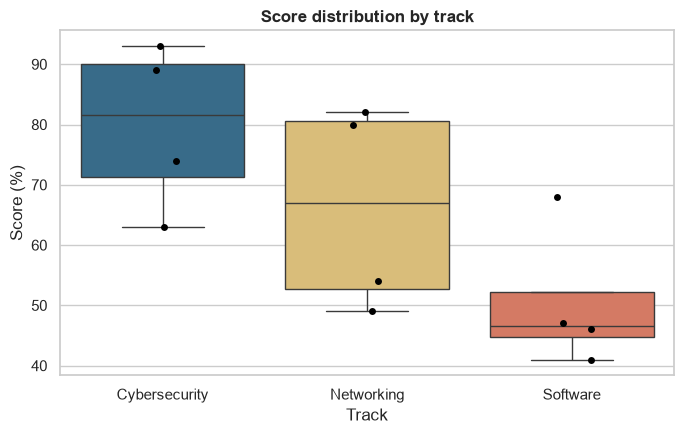

In [147]:
order = df.groupby("Track")["Score"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="Track", y="Score", order=order,
            hue="Track", palette=TRACK_COLORS, legend=False, showfliers=False, ax=ax)
sns.stripplot(data=df, x="Track", y="Score", order=order, color="black", size=5, ax=ax)  # show each trainee
ax.set_title("Score distribution by track")
ax.set_xlabel("Track")
ax.set_ylabel("Score (%)")
plt.tight_layout()
plt.show()

### 8.2 Pie chart (parts of a whole)
Only suitable for **a few categories (about 5 or fewer)** that add up to 100%.

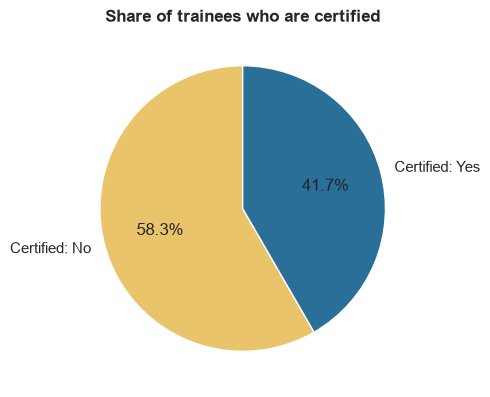

In [148]:
counts = df["Certified"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, labels=[f"Certified: {c}" for c in counts.index], autopct="%1.1f%%", startangle=90,
       colors=["#E9C46A", "#2A6F97"], wedgeprops={"edgecolor": "white"})
ax.set_title("Share of trainees who are certified")
plt.tight_layout()
plt.show()

### 8.3 Heatmap (a matrix of values, e.g. correlations)
Colour shows the strength of the relationship between every pair of numerical variables.

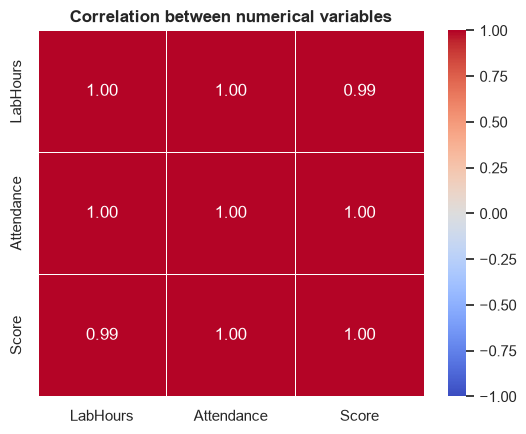

In [ ]:
num_cols = ["LabHours", "Attendance", "Score"]
corr = df[num_cols].corr()                         

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation between numerical variables")
plt.tight_layout()
plt.show()

## 9. Pandas plotting (quick plots straight from a DataFrame)
Pandas has built-in .plot() methods (which use Matplotlib underneath). They need only one line of code, so they are ideal for quick exploration.

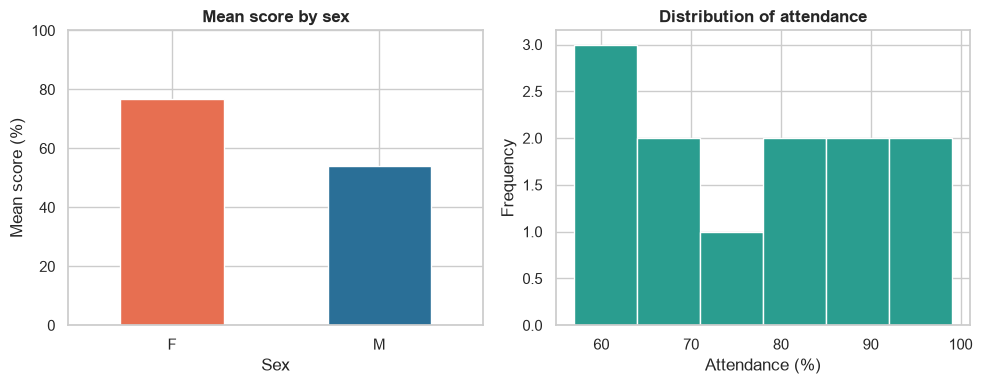

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart in one line
df.groupby("Sex")["Score"].mean().plot(kind="bar", ax=axes[0], color=["#E76F51", "#2A6F97"])
axes[0].set_title("Mean score by sex")
axes[0].set_ylabel("Mean score (%)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

# Histogram in one line
df["Attendance"].plot(kind="hist", bins=6, ax=axes[1], color="#2A9D8F", edgecolor="white")
axes[1].set_title("Distribution of attendance")
axes[1].set_xlabel("Attendance (%)")

plt.tight_layout()
plt.show()

## 10. Interactive charts with Plotly
Plotly Express draws **interactive** charts: hover for exact values (and the trainee's name), zoom, pan and click legend items to hide groups. (Plotly must be installed; charts appear when you run the cells.)

In [151]:
# Interactive scatter plot: hover over a point to see the trainee's details
fig = px.scatter(df, x="LabHours", y="Score", color="Track", color_discrete_map=TRACK_COLORS,
                 hover_name="Trainee", hover_data=["Attendance", "Result", "Certified"],
                 title="Lab hours vs score (interactive)",
                 labels={"LabHours": "Lab hours", "Score": "Score (%)"})
fig.update_traces(marker=dict(size=12))
fig.show(renderer="browser")  

In [152]:
# Interactive box plot and histogram
fig = px.box(df, x="Track", y="Score", color="Track", color_discrete_map=TRACK_COLORS,
             points="all", hover_name="Trainee", title="Score by track (interactive)")
fig.show(renderer="browser")

fig = px.histogram(df, x="Score", nbins=6, color="Result",
                   title="Score distribution by result (interactive)")
fig.show(renderer="browser")  

In [153]:
# Interactive line chart (trainees ordered by lab hours)
long = df_sorted.melt(id_vars=["Trainee", "LabHours"], value_vars=["Score", "Attendance"],
                      var_name="Measure", value_name="Percentage")
fig = px.line(long, x="LabHours", y="Percentage", color="Measure", markers=True,
              hover_name="Trainee", title="Score and attendance by lab hours (interactive)")
fig.show(renderer="browser")

## 11. Best practice in action: honest vs misleading charts
The same data drawn two ways. Cutting the y-axis makes the Software track look tiny next to Cybersecurity, although its mean is about 63% of Cybersecurity's. **Always start bar charts at zero.**

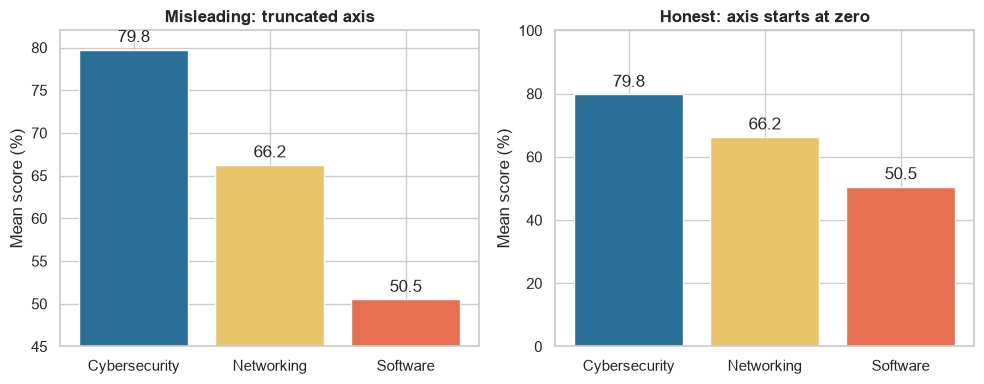

In [154]:
res = df.groupby("Track")["Score"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, ylim, title in [(axes[0], (45, 82), "Misleading: truncated axis"),
                        (axes[1], (0, 100), "Honest: axis starts at zero")]:
    bars = ax.bar(res.index, res.values, color=[TRACK_COLORS[t] for t in res.index])
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_ylabel("Mean score (%)")
plt.tight_layout()
plt.show()

## 12. Putting it together: a small dashboard
Several related charts in one figure using plt.subplots.

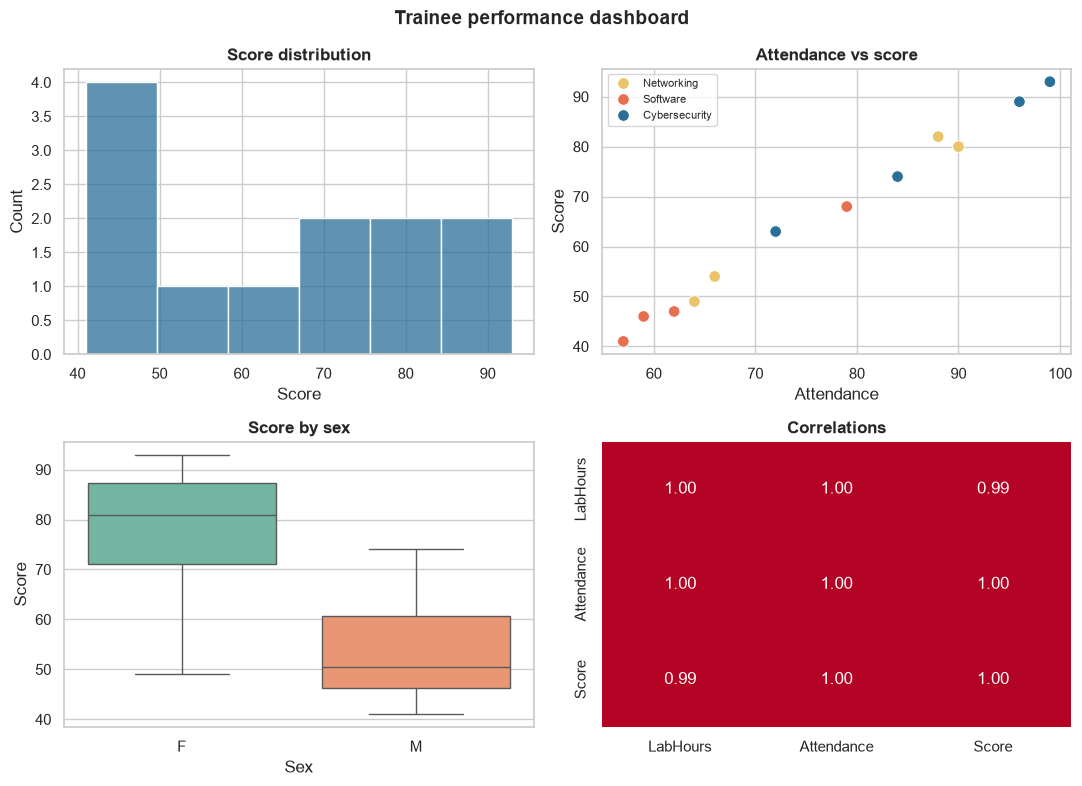

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(df["Score"], bins=6, color="#2A6F97", ax=axes[0, 0])
axes[0, 0].set_title("Score distribution")

sns.scatterplot(data=df, x="Attendance", y="Score", hue="Track", palette=TRACK_COLORS, s=70, ax=axes[0, 1])
axes[0, 1].set_title("Attendance vs score")
axes[0, 1].legend(fontsize=8, title="")

sns.boxplot(data=df, x="Sex", y="Score", hue="Sex", palette="Set2", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Score by sex")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar=False, ax=axes[1, 1])
axes[1, 1].set_title("Correlations")

fig.suptitle("Trainee performance dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Conclusions
* **Histogram** – the 12 scores range from 41 to 93 with a mean of 65.5 and a median of 65.5.
* **Scatter plot, line chart and heatmap** – lab hours, attendance and score rise together almost perfectly (r = 0.99 to 1.00). Correlation does not by itself prove causation, and with 12 trainees this should be treated with caution.
* **Bar chart and box plot** – Cybersecurity has the highest mean score (79.8), then Networking (66.2) and Software (50.5), and the individual points confirm the gaps.
* **Pie chart** – 5 of the 12 trainees (41.7%) are certified; every certified trainee scored 74 or above.
* **Best practices** – clear titles and labels, zero-based bars, one colour per track and showing the individual points for small groups make charts honest and easy to read.
